<a href="https://colab.research.google.com/github/CassandreDGN/PROJET_GPI_CD/blob/master/projetV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet de GPI**:

##First step : binning the image to run the code faster

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO  # Ensure this import is present

from skimage import io, transform
from scipy.signal import correlate2d

%pip install Bio

import urllib.request
#import io
from Bio.PDB import PDBParser, PDBIO
from mpl_toolkits.mplot3d import Axes3D


# Ensure scikit-image is available for bilateral denoising.
if importlib.util.find_spec('skimage') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image'])

from skimage.restoration import denoise_bilateral


# Install required package (run once)
%pip install mrcfile

import mrcfile

%pip install gdown

import gdown
import mrcfile
import os

# if needed, you can install packages using pip
# %pip install scikit-image

# Set random seed for reproducibility
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.4/321.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.0 MB/s eta 0:00:00


Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=293211b5-d0df-4275-941c-2f159b2f95b6
To: /content/map.mrc
100%|██████████| 228M/228M [00:03<00:00, 70.2MB/s]
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (7676, 7420)
Dtype: float32
Min/Max: -3.31172 41.723225

Detected: singlegrowing upbrain map 2D image


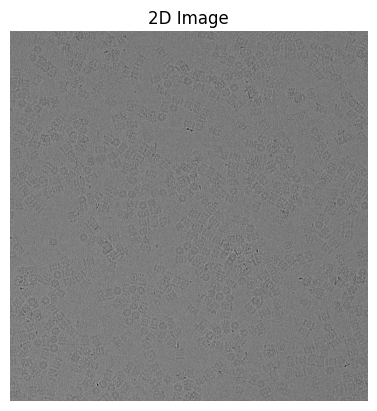

In [ ]:
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = mrc.data.copy()

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: singlegrowing upbrain map 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")

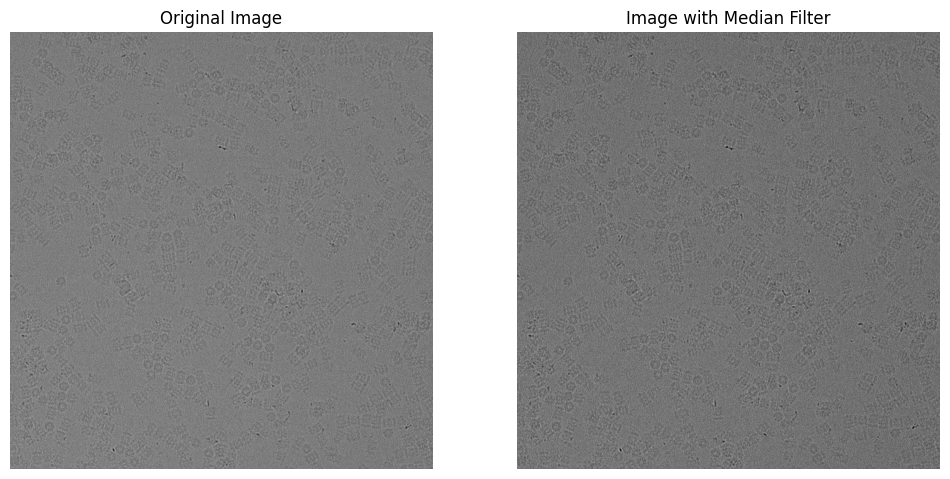

In [ ]:
#add filter on picture to denoise before doing anything else

# Apply median filter
median_filtered_image = ndimage.median_filter(data, size=3)
median_filtered_image = np.clip(median_filtered_image, 0, 255).astype(np.uint8)

# Display the original and filtered images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(data, cmap='gray', vmin=np.percentile(data, 5), vmax=np.percentile(data, 95))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(median_filtered_image, cmap='gray', vmin=np.percentile(data, 5), vmax=np.percentile(data, 95))
ax[1].set_title('Image with Median Filter')
ax[1].axis('off')

plt.show()

In [ ]:
def bin_image(image, bin_size):
    """
    Performs binning (spatial downsampling) on an image.

    Args:
        image: Input image as numpy array
        bin_size: Size of the bin (e.g., 2 for 2x2 binning)

    Returns:
        Binned image with reduced resolution
    """
    h, w = image.shape
    # Calculate new dimensions
    new_h = h // bin_size
    new_w = w // bin_size

    # Reshape and compute mean of each bin
    binned = image[:new_h*bin_size, :new_w*bin_size].reshape(new_h, bin_size, new_w, bin_size)
    binned = binned.mean(axis=(1, 3)).astype(np.uint8)

    return binned

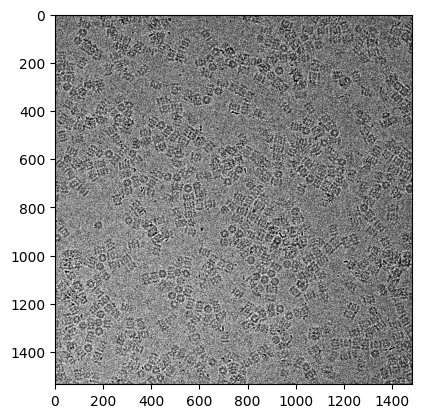

In [ ]:
file_binned = bin_image(median_filtered_image,5)

plt.imshow(file_binned,cmap='gray', vmin=np.percentile(file_binned, 5), vmax=np.percentile(file_binned, 95))

array([[ 0.00428057,  0.00428057, -0.19486332, ..., -0.19486332,
        -0.19486332,  0.00428057],
       [ 0.00428057,  0.00428057,  0.00428057, ...,  0.00428057,
         0.20342446, -0.3940072 ],
       [ 0.20342446,  0.20342446,  0.20342446, ..., -0.19486332,
        -0.19486332, -0.19486332],
       ...,
       [-0.19486332,  0.00428057,  0.20342446, ..., -0.3940072 ,
        -0.19486332, -0.19486332],
       [ 0.20342446, -0.19486332,  0.00428057, ..., -0.19486332,
         0.00428057,  0.20342446],
       [ 0.00428057,  0.00428057,  0.40256834, ..., -0.19486332,
         0.20342446,  0.00428057]])

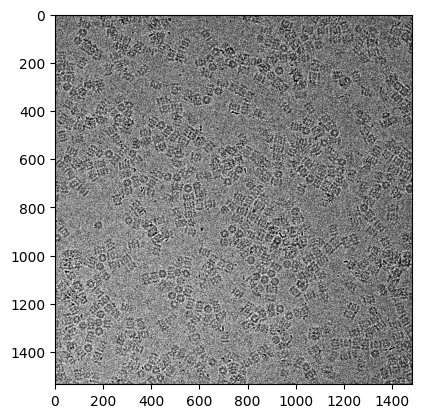

In [ ]:
from mrcfile.dtypes import normalise_byte_order
#normalize image : substract average and divide by max


normalized_data = file_binned - np.mean(file_binned)
normalized_data /= np.max(normalized_data)



vmin2 = np.percentile(normalized_data, 5)
vmax2 = np.percentile(normalized_data, 95)  #have to change vmax value to use the new ones

plt.imshow(normalized_data,cmap='gray',vmin=vmin2, vmax=vmax2)

normalized_data

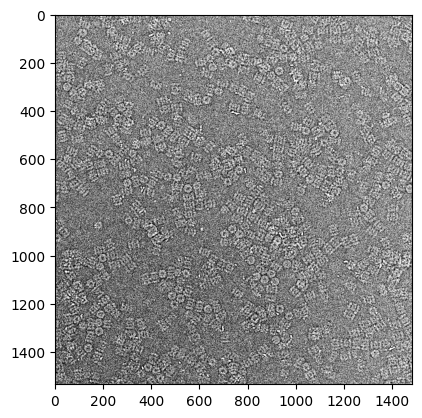

In [ ]:
# inverting picture

binned_normalized_inverted_img = normalized_data*(-1)
plt.imshow(binned_normalized_inverted_img,cmap='gray', vmin=np.percentile(binned_normalized_inverted_img, 5), vmax=np.percentile(binned_normalized_inverted_img, 95))


In [ ]:
# Padding(ton?)
# Function to apply different padding modes
def apply_padding(img, pad_width, mode='constant', constant_value=255):
    """
    Apply padding to an image using NumPy.

    Parameters:rana
        Value used for constant padding

    Returns:
    --------
    padded : ndarray
        Padded image
    """
    if isinstance(pad_width, int):
        pad_width = ((pad_width, pad_width), (pad_width, pad_width))

    if mode == 'constant':
        padded = np.pad(img, pad_width, mode='constant', constant_values=constant_value)
    else:
        padded = np.pad(img, pad_width, mode=mode)

    return padded


to exctrat coordinates we need to figure out a threshold

In [ ]:
#padded_image = apply_padding(normalized_data, 400, mode= 'constant', constant_value=255)

padded_image = apply_padding(binned_normalized_inverted_img, 70, mode= 'edge')

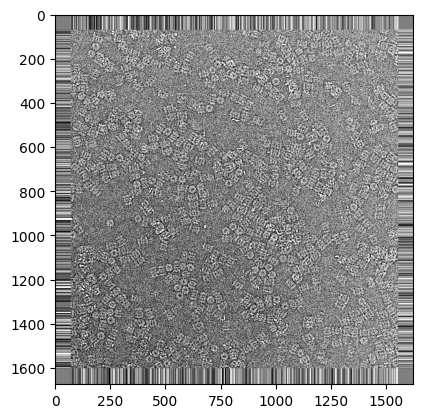

In [ ]:
plt.imshow(padded_image,cmap='gray',vmin=np.percentile(padded_image, 5),vmax=np.percentile(padded_image, 95))

### still have to denoise and crop to make test image but anyway moving on

## Projection

PART 7: PDB FILES - PROTEIN STRUCTURES & 2D PROJECTIONS

📚 WHAT IS A PDB FILE?

PDB (Protein Data Bank) Format:
  - Standard text format for storing 3D atomic structures
  - Contains coordinates of atoms in proteins, DNA, RNA, small molecules
  - Publicly available at: https://www.rcsb.org/

PDB File Structure:
  - HEADER: Basic information about the structure
  - TITLE: Name/description of the molecule
  - ATOM records: X, Y, Z coordinates of each atom
  - HETATM: Heterogeneous atoms (ligands, water, ions)
  - CONECT: Connectivity information between atoms
  - END: Marks end of file

Each structure has a 4-character PDB ID (e.g., 6BDF)
  - First 3 characters: Unique identifier
  - Last character: Chain ID

Applications:
  - Drug discovery and molecular docking
  - Protein structure validation
  - Creating 2D projections (electron microscopy simulation)
  - Computational biology research


📥 FETCHING PDB STRUCTURE: 6BDF
✓ Successfully downloaded 3885327 bytes
✓ Saved to 6BDF.pdb

🔬 STR

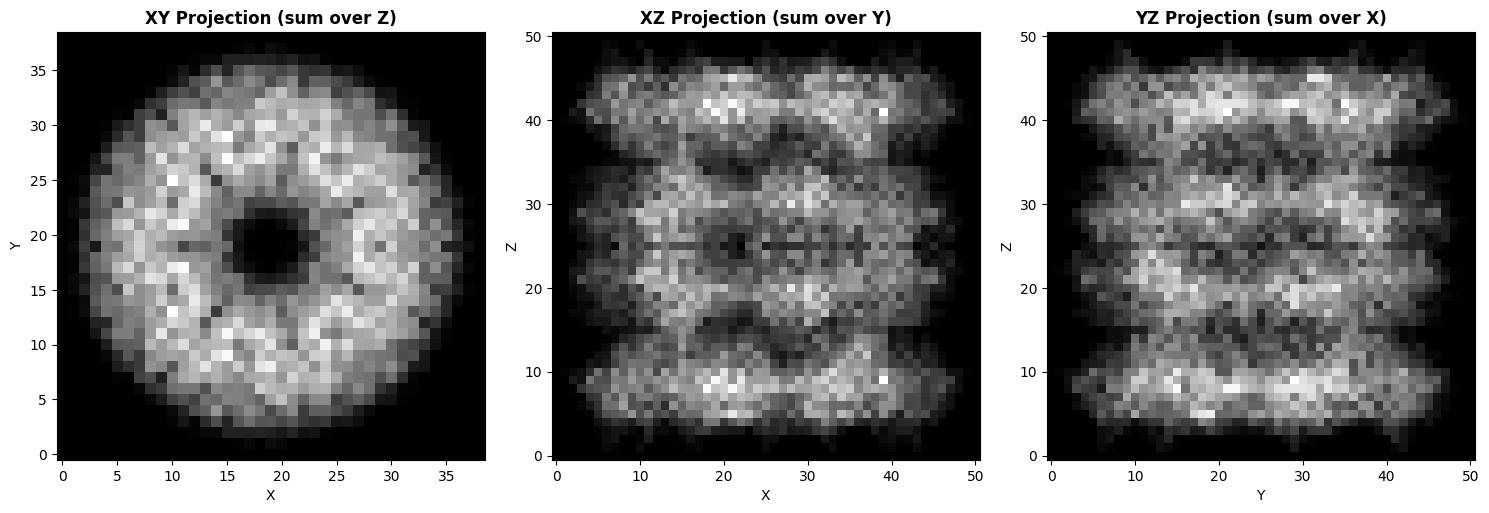


Summed Density Projections:
  - Pixel intensity = number of atoms projected into that pixel
  - Brighter = higher density
  - Approximates ideal projection images (no noise, no CTF)


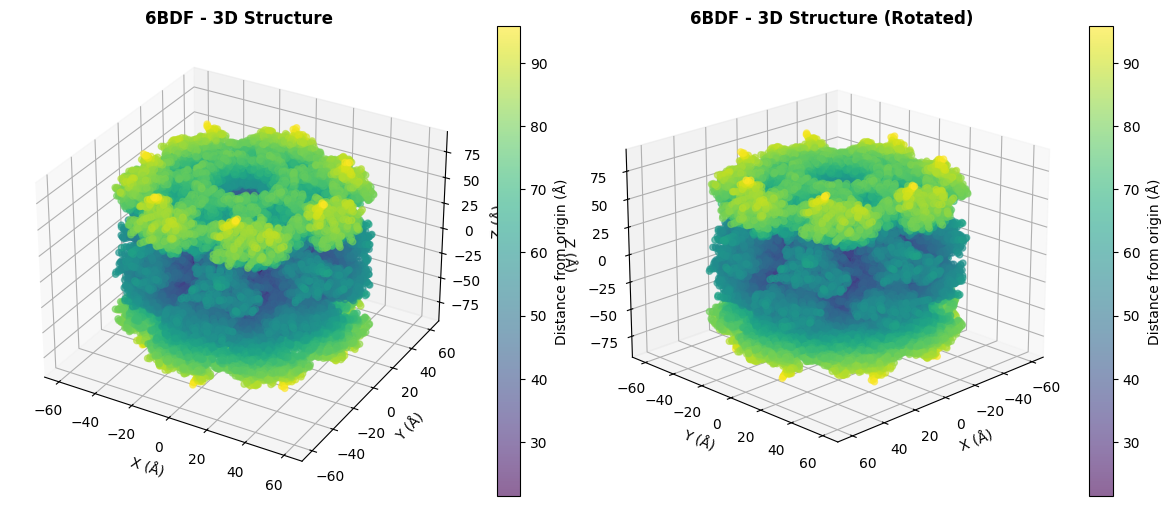

In [ ]:
print("="*70)
print("PART 7: PDB FILES - PROTEIN STRUCTURES & 2D PROJECTIONS")
print("="*70)

print("\n" + "="*70)
print("📚 WHAT IS A PDB FILE?")
print("="*70)
print("""
PDB (Protein Data Bank) Format:
  - Standard text format for storing 3D atomic structures
  - Contains coordinates of atoms in proteins, DNA, RNA, small molecules
  - Publicly available at: https://www.rcsb.org/

PDB File Structure:
  - HEADER: Basic information about the structure
  - TITLE: Name/description of the molecule
  - ATOM records: X, Y, Z coordinates of each atom
  - HETATM: Heterogeneous atoms (ligands, water, ions)
  - CONECT: Connectivity information between atoms
  - END: Marks end of file

Each structure has a 4-character PDB ID (e.g., 6BDF)
  - First 3 characters: Unique identifier
  - Last character: Chain ID

Applications:
  - Drug discovery and molecular docking
  - Protein structure validation
  - Creating 2D projections (electron microscopy simulation)
  - Computational biology research
""")

print("\n" + "="*70)
print("📥 FETCHING PDB STRUCTURE: 6BDF")
print("="*70)

pdb_id = "6BDF"
pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

try:
    print(f"Downloading {pdb_id} from RCSB PDB...")
    with urllib.request.urlopen(pdb_url, timeout=10) as response:
        pdb_content = response.read().decode('utf-8')
    print(f"✓ Successfully downloaded {len(pdb_content)} bytes")

    # Save to file
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, 'w') as f:
        f.write(pdb_content)
    print(f"✓ Saved to {pdb_file}")

    # Parse the PDB file
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, pdb_file)

    print("\n" + "="*70)
    print("🔬 STRUCTURE INFORMATION")
    print("="*70)

    # Extract information
    model = structure[0]
    chains = list(model.get_chains())

    print(f"\nStructure ID: {pdb_id}")
    print(f"Number of models: {len(structure)}")
    print(f"Number of chains: {len(chains)}")

    for chain in chains:
        residues = list(chain.get_residues())
        atoms = list(chain.get_atoms())
        print(f"\nChain {chain.id}:")
        print(f"  - Residues: {len(residues)}")
        print(f"  - Atoms: {len(atoms)}")


    # Extract t 7: Manipulating a PDt 7: Manipulating a PD coordinates
    print("\n" + "="*70)
    print("🧬 ATOMIC COORDINATES FROM 6BDF")
    print("="*70)

    all_atoms = []
    for chain in model.get_chains():
        for residue in chain.get_residues():
            for atom in residue.get_atoms():
                coord = atom.get_coord()
                all_atoms.append({
                    'name': atom.name,
                    'residue': residue.resname,
                    'residue_id': residue.id[1],
                    'x': coord[0],
                    'y': coord[1],
                    'z': coord[2],
                    'b_factor': atom.bfactor
                })

    print(f"Total atoms: {len(all_atoms)}")
    print(f"\nFirst 10 atoms:")
    print(f"{'Atom':6} {'Residue':8} {'Res#':5} {'X (Å)':10} {'Y (Å)':10} {'Z (Å)':10} {'B-factor':10}")
    print("-" * 60)
    for atom in all_atoms[:10]:
        print(f"{atom['name']:6} {atom['residue']:8} {atom['residue_id']:5d} {atom['x']:10.3f} {atom['y']:10.3f} {atom['z']:10.3f} {atom['b_factor']:10.2f}")

    # Extract coordinates for visualization
    coords = np.array([[atom['x'], atom['y'], atom['z']] for atom in all_atoms])

    print(f"\nCoordinate statistics:")
    print(f"  X range: [{coords[:, 0].min():.3f}, {coords[:, 0].max():.3f}] Å")
    print(f"  Y range: [{coords[:, 1].min():.3f}, {coords[:, 1].max():.3f}] Å")
    print(f"  Z range: [{coords[:, 2].min():.3f}, {coords[:, 2].max():.3f}] Å")

    print("\n" + "="*70)
    print("🎯 CREATING DENSITY-BASED 2D PROJECTIONS (SUMMED GRAYSCALE)")
    print("="*70)

    # Center coordinates
    coords_centered = coords - coords.mean(axis=0)
    padding = 5     # Å padding around structure

    # =========================================================================
    # 1. DEFINE PROJECTION ENGINE FIRST
    # =========================================================================
    def create_projection(coord1, coord2, bins=256):
        min1, max1 = coord1.min() - padding, coord1.max() + padding
        min2, max2 = coord2.min() - padding, coord2.max() + padding

        # 2D histogram (counts = density)
        H, xedges, yedges = np.histogram2d(coord1, coord2, bins=bins,
                                           range=[[min1, max1], [min2, max2]])
        return H / H.max()

    # =========================================================================
    # 2. DYNAMIC CANVAS RESOLUTION SCALE (Zero Hardcoded Values)
    # =========================================================================
    total_physical_span = coords_centered.max() - coords_centered.min()
    angstroms_per_pixel = total_physical_span / 48.0  # Dynamic baseline aspect ratio

    # =========================================================================
    # 3. RUN PROJECTIONS (Updating the single 'img_size' variable on the fly)
    # =========================================================================

    # XY (Top View)
    span_xy = max(coords_centered[:, 0].max() - coords_centered[:, 0].min(),
                  coords_centered[:, 1].max() - coords_centered[:, 1].min()) + (2 * padding)
    img_size = int(np.ceil(span_xy / angstroms_per_pixel))
    proj_xy = create_projection(coords_centered[:, 0], coords_centered[:, 1], img_size)

    # XZ (Side View)
    span_xz = max(coords_centered[:, 0].max() - coords_centered[:, 0].min(),
                  coords_centered[:, 2].max() - coords_centered[:, 2].min()) + (2 * padding)
    img_size = int(np.ceil(span_xz / angstroms_per_pixel))
    proj_xz = create_projection(coords_centered[:, 0], coords_centered[:, 2], img_size)

    # YZ (Alternate Side View)
    span_yz = max(coords_centered[:, 1].max() - coords_centered[:, 1].min(),
                  coords_centered[:, 2].max() - coords_centered[:, 2].min()) + (2 * padding)
    img_size = int(np.ceil(span_yz / angstroms_per_pixel))
    proj_yz = create_projection(coords_centered[:, 1], coords_centered[:, 2], img_size)

    # =========================================================================

    # Plot projections
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # XY projection
    axes[0].imshow(proj_xy.T, cmap='gray', origin='lower')
    axes[0].set_title('XY Projection (sum over Z)', fontweight='bold')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')

    # XZ projection
    axes[1].imshow(proj_xz.T, cmap='gray', origin='lower')
    axes[1].set_title('XZ Projection (sum over Y)', fontweight='bold')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Z')

    # YZ projection
    axes[2].imshow(proj_yz.T, cmap='gray', origin='lower')
    axes[2].set_title('YZ Projection (sum over X)', fontweight='bold')
    axes[2].set_xlabel('Y')
    axes[2].set_ylabel('Z')

    plt.tight_layout()
    plt.show()

    print("\nSummed Density Projections:")
    print("  - Pixel intensity = number of atoms projected into that pixel")
    print("  - Brighter = higher density")
    print("  - Approximates ideal projection images (no noise, no CTF)")

    # 3D visualization
    fig = plt.figure(figsize=(12, 5))

    # 3D scatter plot
    ax4 = fig.add_subplot(1, 2, 1, projection='3d')
    scatter = ax4.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                          c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax4.set_xlabel('X (Å)', fontsize=10)
    ax4.set_ylabel('Y (Å)', fontsize=10)
    ax4.set_zlabel('Z (Å)', fontsize=10)
    ax4.set_title(f'{pdb_id} - 3D Structure', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax4, label='Distance from origin (Å)')

    # 3D scatter plot - rotated view
    ax5 = fig.add_subplot(1, 2, 2, projection='3d')
    scatter2 = ax5.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                           c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax5.view_init(elev=20, azim=45)  # Different viewing angle
    ax5.set_xlabel('X (Å)', fontsize=10)
    ax5.set_ylabel('Y (Å)', fontsize=10)
    ax5.set_zlabel('Z (Å)', fontsize=10)
    ax5.set_title(f'{pdb_id} - 3D Structure (Rotated)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter2, ax=ax5, label='Distance from origin (Å)')

    plt.tight_layout()
    plt.show()


except urllib.error.URLError as e:
    print(f"❌ Error downloading PDB file: {e}")
    print("   Make sure you have internet connection")
except Exception as e:
    print(f"❌ Error: {type(e).__name__}: {e}")

cut the micrograph in very little little pieces to test the cross-correlation without spending 5hours and 52 minutes waiting for the script to run cause that would be really fucking fucking dumb ngl

also figure out how to get the images in tif format like are they? are they not?

In [ ]:
def cross_correlation(image, template):
    """
    Perform 2D cross-correlation (simple version).

    Parameters:
    -----------
    image : 2D numpy array
        Input image
    template : 2D numpy array
        Template to search for

    Returns:
    --------
    output : 2D numpy array
        Cross-correlation result
    """
    img_h, img_w = image.shape
    tmp_h, tmp_w = template.shape

    # Output size
    out_h = img_h - tmp_h + 1
    out_w = img_w - tmp_w + 1

    output = np.zeros((out_h, out_w))

    # Slide template over image
    for i in range(out_h):
        for j in range(out_w):
            region = image[i:i+tmp_h, j:j+tmp_w]
            # Cross-correlation: element-wise multiplication and sum
            output[i, j] = np.sum(region * template)

    return output

# Test with simple example
simple_image = np.array([
    [1, 2, 3, 2, 1],
    [2, 3, 4, 3, 2],
    [3, 4, 5, 4, 3],
    [2, 3, 4, 3, 2],
    [1, 2, 3, 2, 1]
], dtype=float)

simple_template = np.array([
    [3, 4, 3],
    [4, 5, 4],
    [3, 4, 3]
], dtype=float)

cc_result = cross_correlation(simple_image, simple_template)

print("Image:")
print(simple_image)
print("\nTemplate:")
print(simple_template)
print("\nCross-correlation result:")
print(cc_result)
print("\nMax value at position:", np.unravel_index(cc_result.argmax(), cc_result.shape))
print("This means template matches best at center (1,1)!")

Image:
[[1. 2. 3. 2. 1.]
 [2. 3. 4. 3. 2.]
 [3. 4. 5. 4. 3.]
 [2. 3. 4. 3. 2.]
 [1. 2. 3. 2. 1.]]

Template:
[[3. 4. 3.]
 [4. 5. 4.]
 [3. 4. 3.]]

Cross-correlation result:
[[ 99. 112.  99.]
 [112. 125. 112.]
 [ 99. 112.  99.]]

Max value at position: (np.int64(1), np.int64(1))
This means template matches best at center (1,1)!


In [ ]:
def normalized_cross_correlation(image, template):
    """
    Perform normalized cross-correlation.

    Parameters:
    -----------
    image : 2D numpy array
        Input image
    template : 2D numpy array
        Template to search for

    Returns:
    --------
    output : 2D numpy array
        Normalized cross-correlation (values between -1 and 1)
    """
    img_h, img_w = image.shape
    tmp_h, tmp_w = template.shape

    out_h = img_h - tmp_h + 1
    out_w = img_w - tmp_w + 1

    output = np.zeros((out_h, out_w))

    # Normalize template (subtract mean)
    template_mean = template.mean()
    template_norm = template - template_mean
    template_std = np.sqrt(np.sum(template_norm ** 2))

    # Avoid division by zero
    if template_std == 0:
        return output

    # Slide template over image
    for i in range(out_h):
        for j in range(out_w):
            region = image[i:i+tmp_h, j:j+tmp_w]

            # Normalize region
            region_mean = region.mean()
            region_norm = region - region_mean
            region_std = np.sqrt(np.sum(region_norm ** 2))

            # Avoid division by zero
            if region_std == 0:
                output[i, j] = 0
            else:
                # Normalized cross-correlation
                output[i, j] = np.sum(region_norm * template_norm) / (region_std * template_std)

    return output

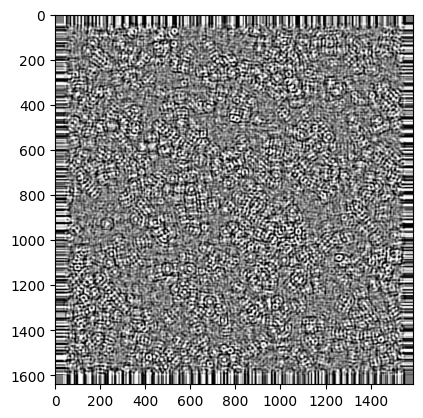

In [ ]:
ncc_image = normalized_cross_correlation(padded_image, proj_xy)
plt.imshow(ncc_image,cmap='gray',vmin=np.percentile(ncc_image, 5),vmax=np.percentile(ncc_image, 95))


In [ ]:
  def template_matching(image, template, method='ncc'):
    """
    Perform template matching with padding.

    Parameters:
    -----------
    image : 2D numpy array
        Input image
    template : 2D numpy array
        Template to search for
    method : str
        'ncc' for normalized cross-correlation
        'cc' for simple cross-correlation

    Returns:
    --------
    result : 2D numpy array (same size as input image)
        Matching score map
    """
    tmp_h, tmp_w = template.shape
    pad_h, pad_w = tmp_h // 2, tmp_w // 2

    # Pad image
    padded = np.pad(image,
                    ((pad_h, pad_h), (pad_w, pad_w)),
                    mode='constant',
                    constant_values=0)

    # Perform matching
    if method == 'ncc':
        result = normalized_cross_correlation(padded, template)
    else:
        result = cross_correlation(padded, template)

    return result



# Apply template matching
match_result = template_matching(padded_image, proj_xy, method='ncc')

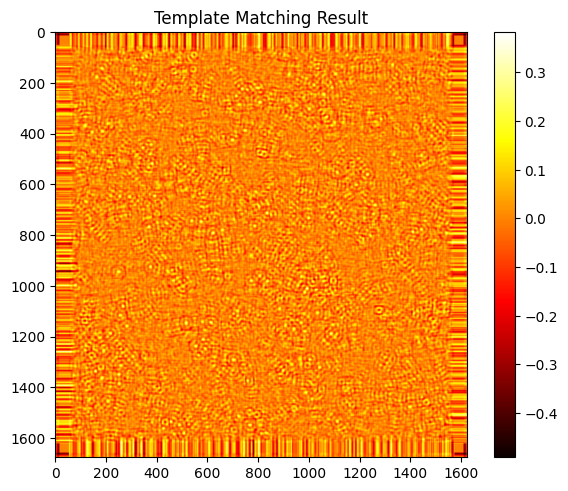

In [ ]:
# Create a single plot for the match result
plt.figure(figsize=(6, 5))

# Display the result map
im = plt.imshow(match_result, cmap='hot')
plt.title('Template Matching Result')
plt.colorbar(im)

plt.tight_layout()
plt.show()

Total fully-contained particles isolated: 184


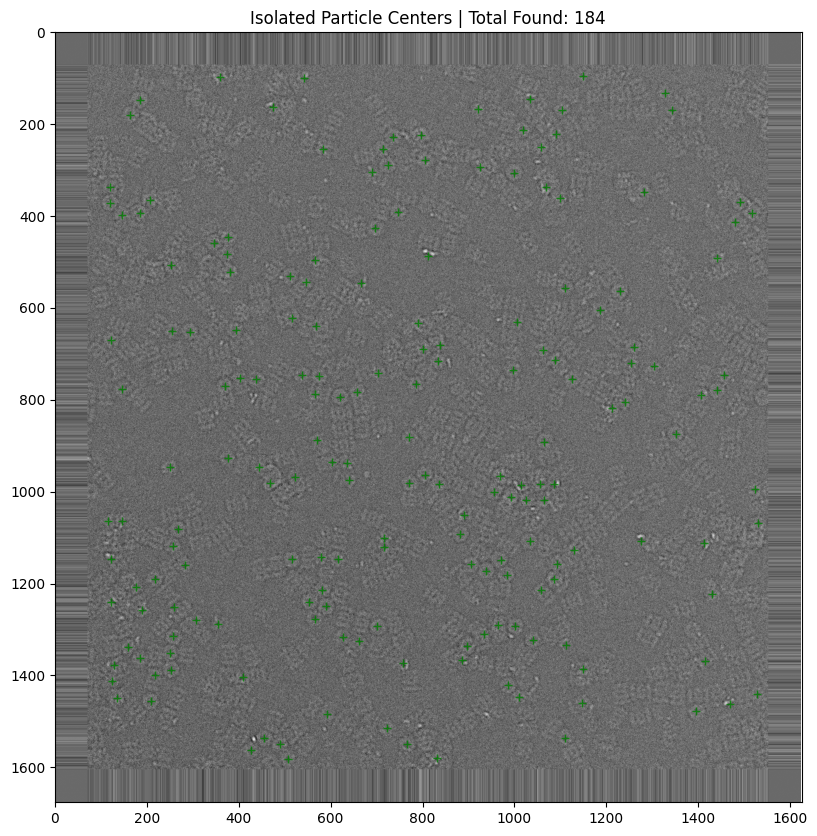

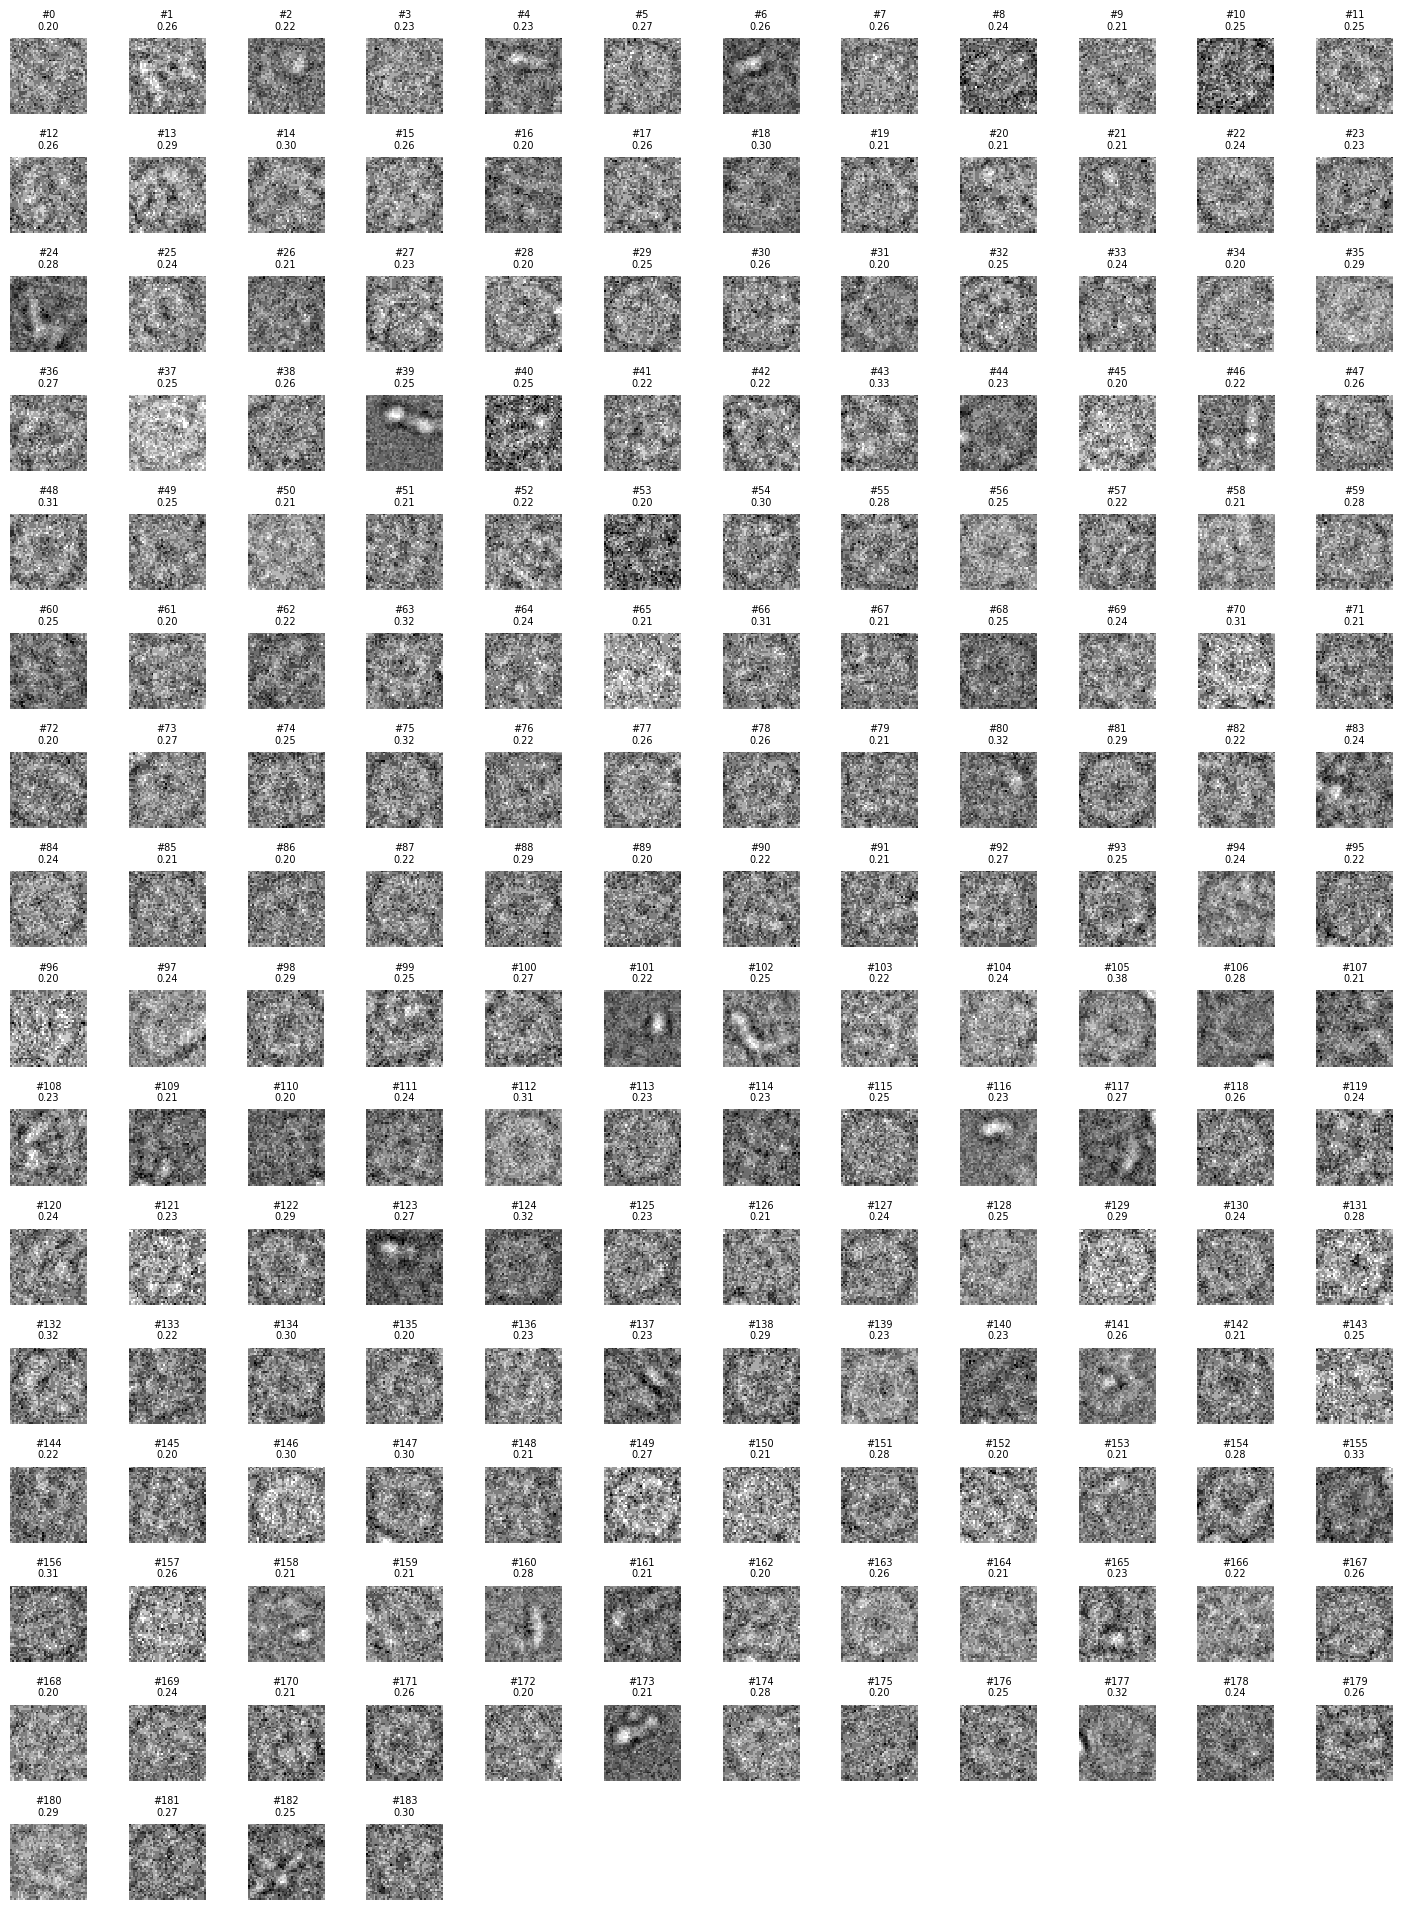

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

# 1. Enforce strict safety boundary masking (pad width + gallery crop radius)
pad_w = 70
pad_h = 70
crop_radius = 20  # Matches the crop size we use to make the gallery boxes

# We push the mask boundary in by an extra 20px so the crop boxes never hit the edge
safe_bound_h = pad_h + crop_radius
safe_bound_w = pad_w + crop_radius
h, w = match_result.shape

valid_mask = np.zeros_like(match_result, dtype=bool)
valid_mask[safe_bound_h : h - safe_bound_h, safe_bound_w : w - safe_bound_w] = True
clean_match_result = match_result * valid_mask

# 2. Peak Finding (Finds the single highest pixel for each particle cluster)
neighborhood_size = 40
local_max = ndimage.maximum_filter(clean_match_result, size=neighborhood_size)

chosen_threshold = 0.20
peaks = (clean_match_result == local_max) & (clean_match_result > chosen_threshold)

# Extract precise, isolated coordinates
isolated_y, isolated_x = np.where(peaks)
total_particles = len(isolated_x)

print(f"Total fully-contained particles isolated: {total_particles}")

# 3. Plot 1: Main verification map with clean crosshairs
plt.figure(figsize=(10, 10))
plt.imshow(padded_image, cmap='gray')
plt.scatter(isolated_x, isolated_y, c='g', marker='+', s=30, linewidths=1, alpha=0.8)
plt.title(f'Isolated Particle Centers | Total Found: {total_particles}')
plt.xlim(0, w)
plt.ylim(h, 0)
plt.show()

# 4. Plot 2: Sharp Full Particle Gallery (No more math module needed)
cols = 12
rows = (total_particles + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
axes = axes.ravel()

for i in range(total_particles):
    cy, cx = isolated_y[i], isolated_x[i]
    score = clean_match_result[cy, cx]

    # Extract the localized patch from the original image
    patch = padded_image[cy - crop_radius : cy + crop_radius + 1,
                         cx - crop_radius : cx + crop_radius + 1]

    if patch.size > 0:
        # interpolation='nearest' stops the blurriness completely
        axes[i].imshow(patch, cmap='gray', interpolation='nearest')
        axes[i].set_title(f"#{i}\n{score:.2f}", fontsize=7)
    axes[i].axis('off')

# Hide any leftover empty subplots on the last row
for j in range(total_particles, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

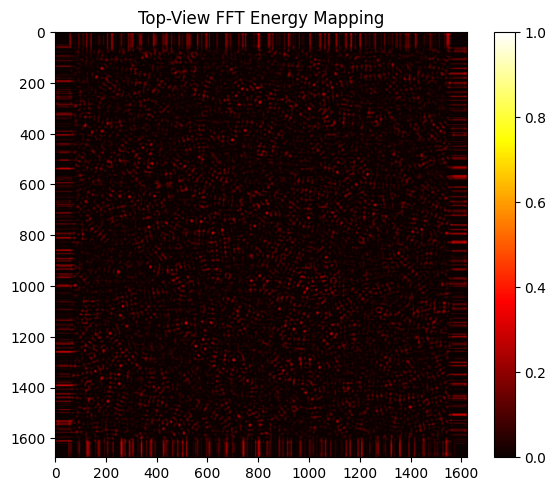

Total fully-contained top-view particles isolated: 200


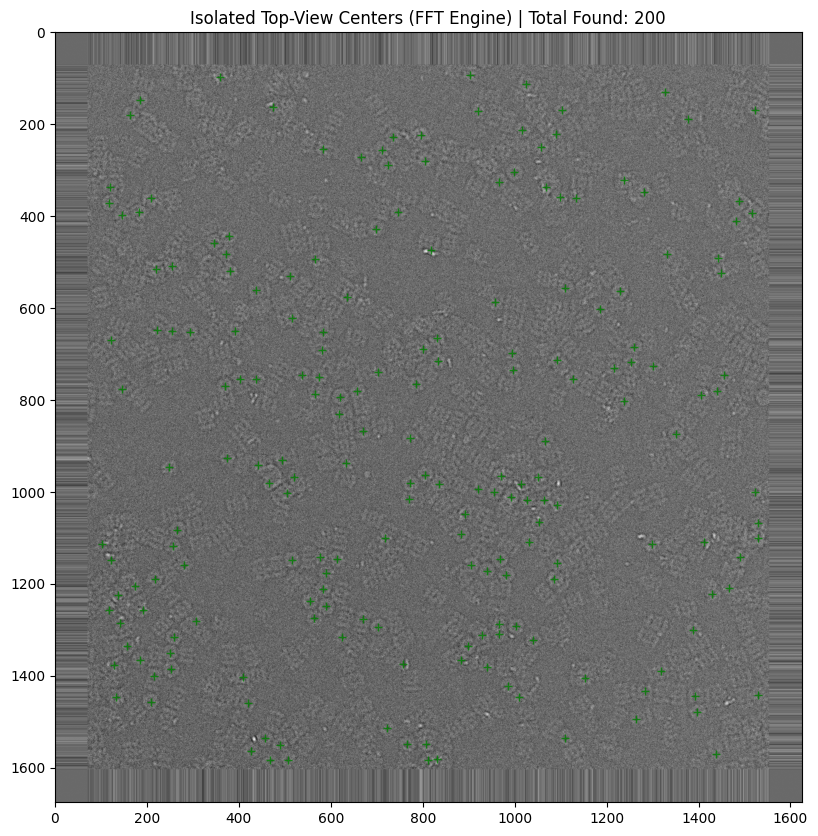

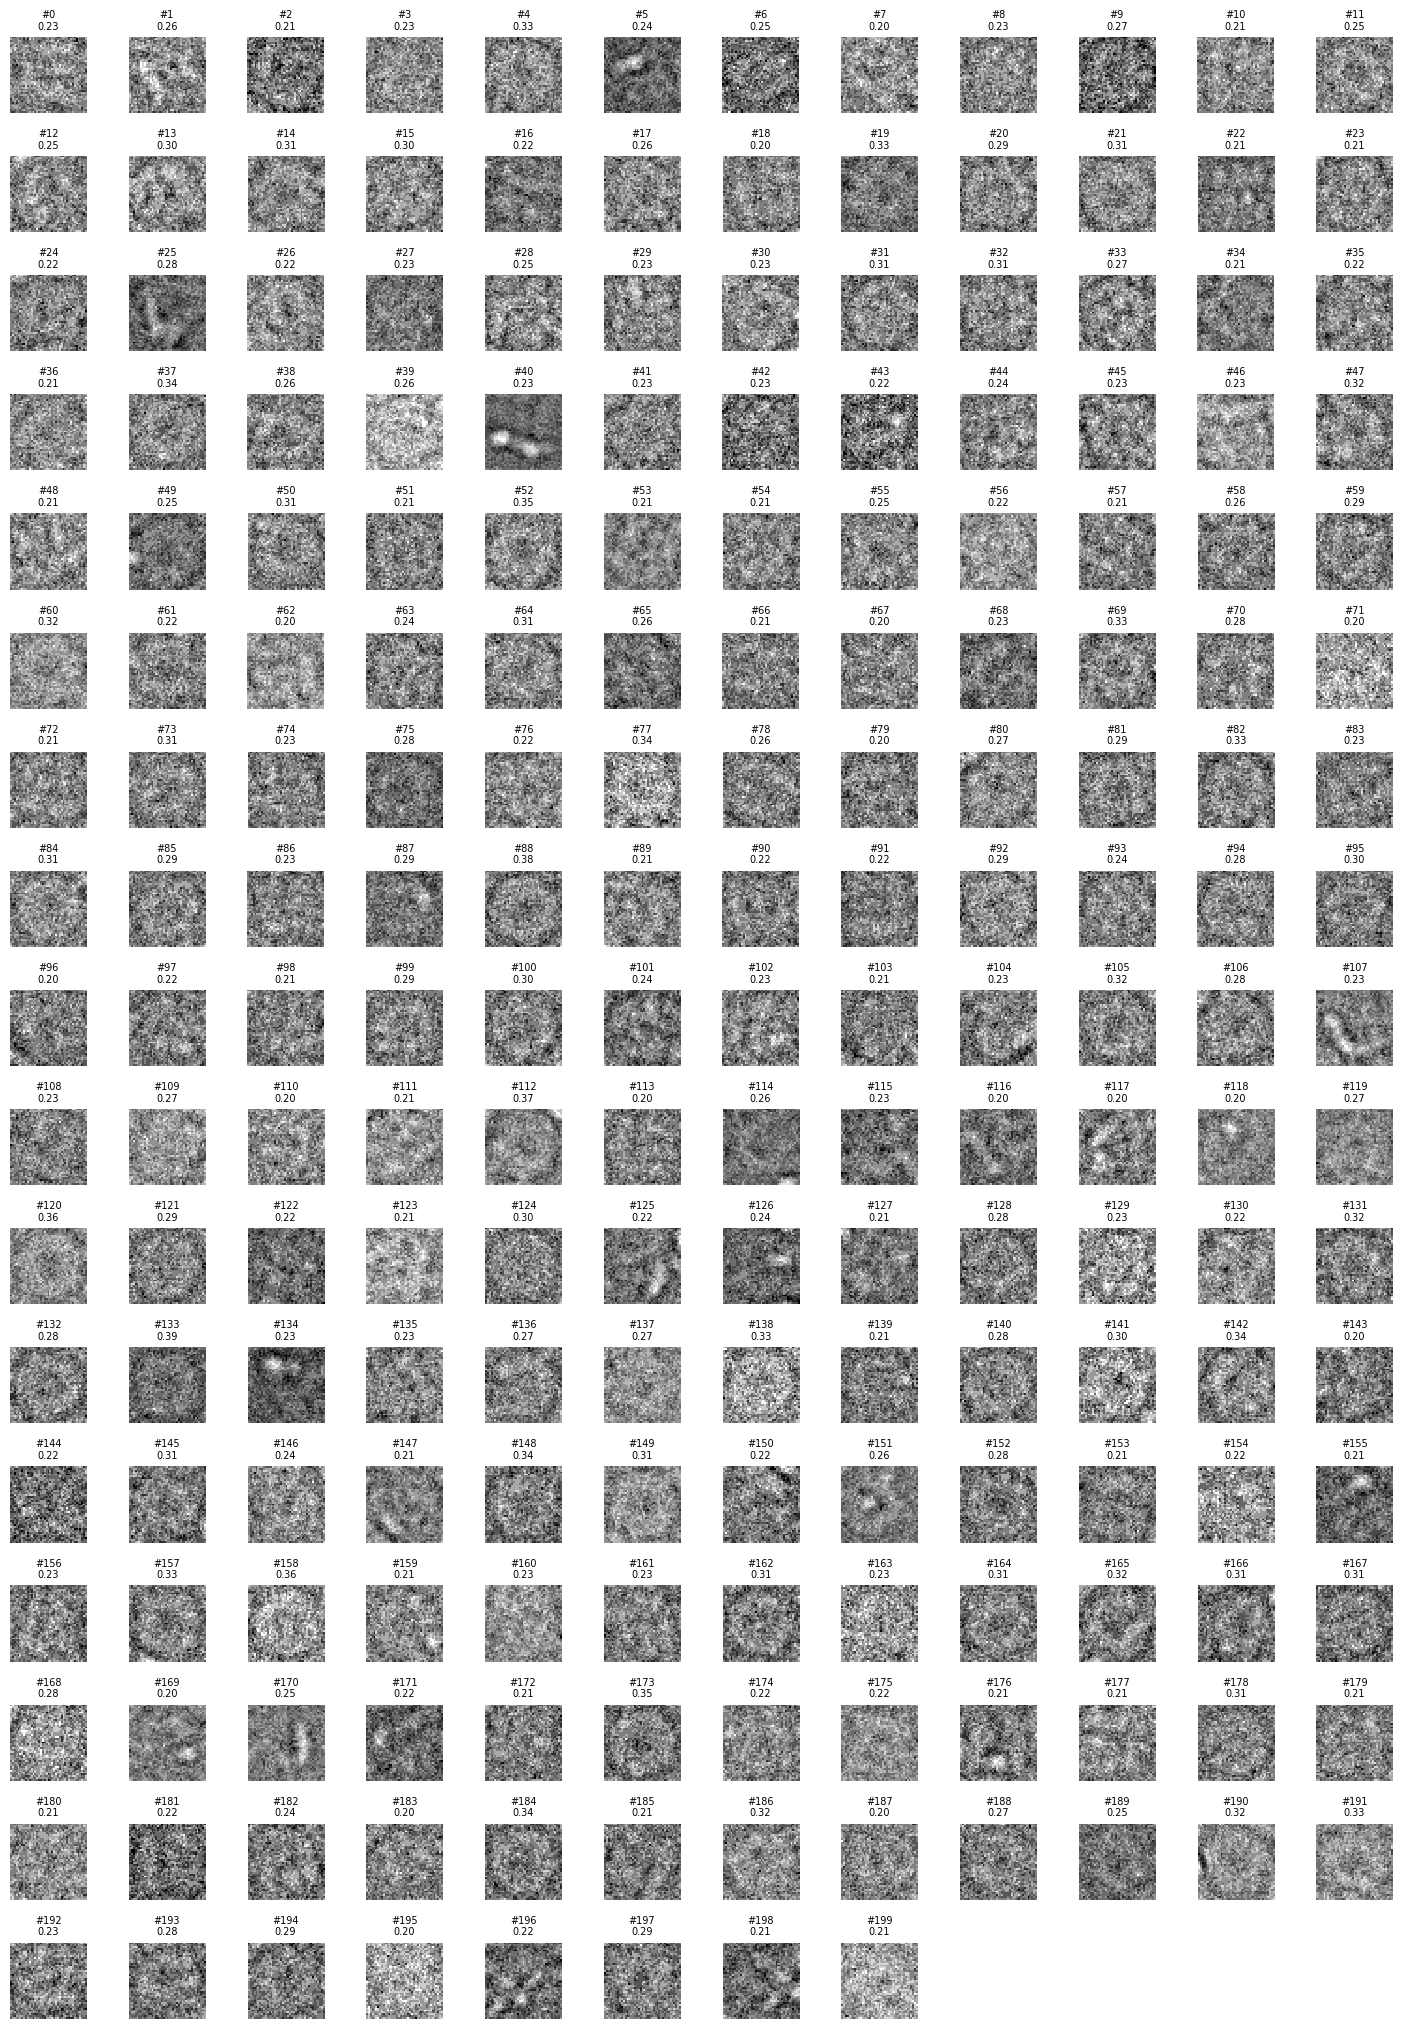

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
from scipy.signal import fftconvolve

# =========================================================================
# 1. FREQUENCY-DOMAIN NORMALIZED TEMPLATE MATCHING (FFT)
# =========================================================================
def template_matching_fft(image, template):
    """
    Compares the projection template against every box in the micrograph
    simultaneously using frequency-domain cross-correlation.
    """
    img = image.astype(np.float64)
    tmpl = template.astype(np.float64)

    # Zero-mean the template so background shifts don't warp the scores
    tmpl -= tmpl.mean()
    tmpl_energy = np.sqrt(np.sum(tmpl ** 2))
    if tmpl_energy == 0:
        return np.zeros_like(img)
    tmpl /= tmpl_energy

    # FFT Cross-Correlation via convolution (flipping the template anchors it)
    corr = fftconvolve(img, tmpl[::-1, ::-1], mode='same')

    # Parse local box variances across the micrograph to enforce strict normalization
    n = tmpl.size
    ones = np.ones_like(tmpl)
    local_sum = fftconvolve(img, ones, mode='same')
    local_sum_sq = fftconvolve(img ** 2, ones, mode='same')

    local_var = np.maximum(local_sum_sq / n - (local_sum / n) ** 2, 0.0)
    local_std = np.sqrt(local_var)

    # Scale matching scores strictly between -1.0 and 1.0
    with np.errstate(divide='ignore', invalid='ignore'):
        ncc_map = corr / (np.sqrt(n) * local_std)
        ncc_map[local_std < 1e-10] = 0.0

    return ncc_map

# Run the frequency domain search pass
match_result = template_matching_fft(padded_image, proj_xy)

# Verify the raw correlation mapping
plt.figure(figsize=(6, 5))
im = plt.imshow(match_result, cmap='hot', vmin=0.0, vmax=1.0)
plt.title('Top-View FFT Energy Mapping')
plt.colorbar(im)
plt.tight_layout()
plt.show()

# =========================================================================
# 2. EDGE BOUNDARY SAFE MASKING
# =========================================================================
pad_w, pad_h, crop_radius = 70, 70, 20
safe_bound_h = pad_h + crop_radius
safe_bound_w = pad_w + crop_radius
h, w = match_result.shape

valid_mask = np.zeros_like(match_result, dtype=bool)
valid_mask[safe_bound_h : h - safe_bound_h, safe_bound_w : w - safe_bound_w] = True
clean_match_result = match_result * valid_mask

# =========================================================================
# 3. PEAK EXTRACTION & COORDINATE ISOLATION
# =========================================================================
neighborhood_size = 40
local_max = ndimage.maximum_filter(clean_match_result, size=neighborhood_size)

# Adjust this threshold if you want to be more or less strict with the circles
chosen_threshold = 0.20
peaks = (clean_match_result == local_max) & (clean_match_result > chosen_threshold)

isolated_y, isolated_x = np.where(peaks)
total_particles = len(isolated_x)
print(f"Total fully-contained top-view particles isolated: {total_particles}")

# =========================================================================
# 4. MICROGRAPH CROSSHAIR VERIFICATION MAP
# =========================================================================
plt.figure(figsize=(10, 10))
plt.imshow(padded_image, cmap='gray')
plt.scatter(isolated_x, isolated_y, c='g', marker='+', s=30, linewidths=1, alpha=0.8)
plt.title(f'Isolated Top-View Centers (FFT Engine) | Total Found: {total_particles}')
plt.xlim(0, w)
plt.ylim(h, 0)
plt.show()
# =========================================================================
# 5. SHARP TOP-VIEW VISUAL GALLERY GRID
# =========================================================================
if total_particles > 0:
    cols = 12
    rows = (total_particles + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
    axes = axes.ravel() if total_particles > 1 else [axes]

    for i in range(total_particles):
        cy, cx = isolated_y[i], isolated_x[i]
        score = clean_match_result[cy, cx]

        # Extract the patch from the original padded image
        patch = padded_image[cy - crop_radius : cy + crop_radius + 1,
                             cx - crop_radius : cx + crop_radius + 1]

        if patch.size > 0:
            axes[i].imshow(patch, cmap='gray', interpolation='nearest')
            axes[i].set_title(f"#{i}\n{score:.2f}", fontsize=7)
        axes[i].axis('off')

    # Hide any empty subplots at the end of the grid
    for j in range(total_particles, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Now doing side view rip

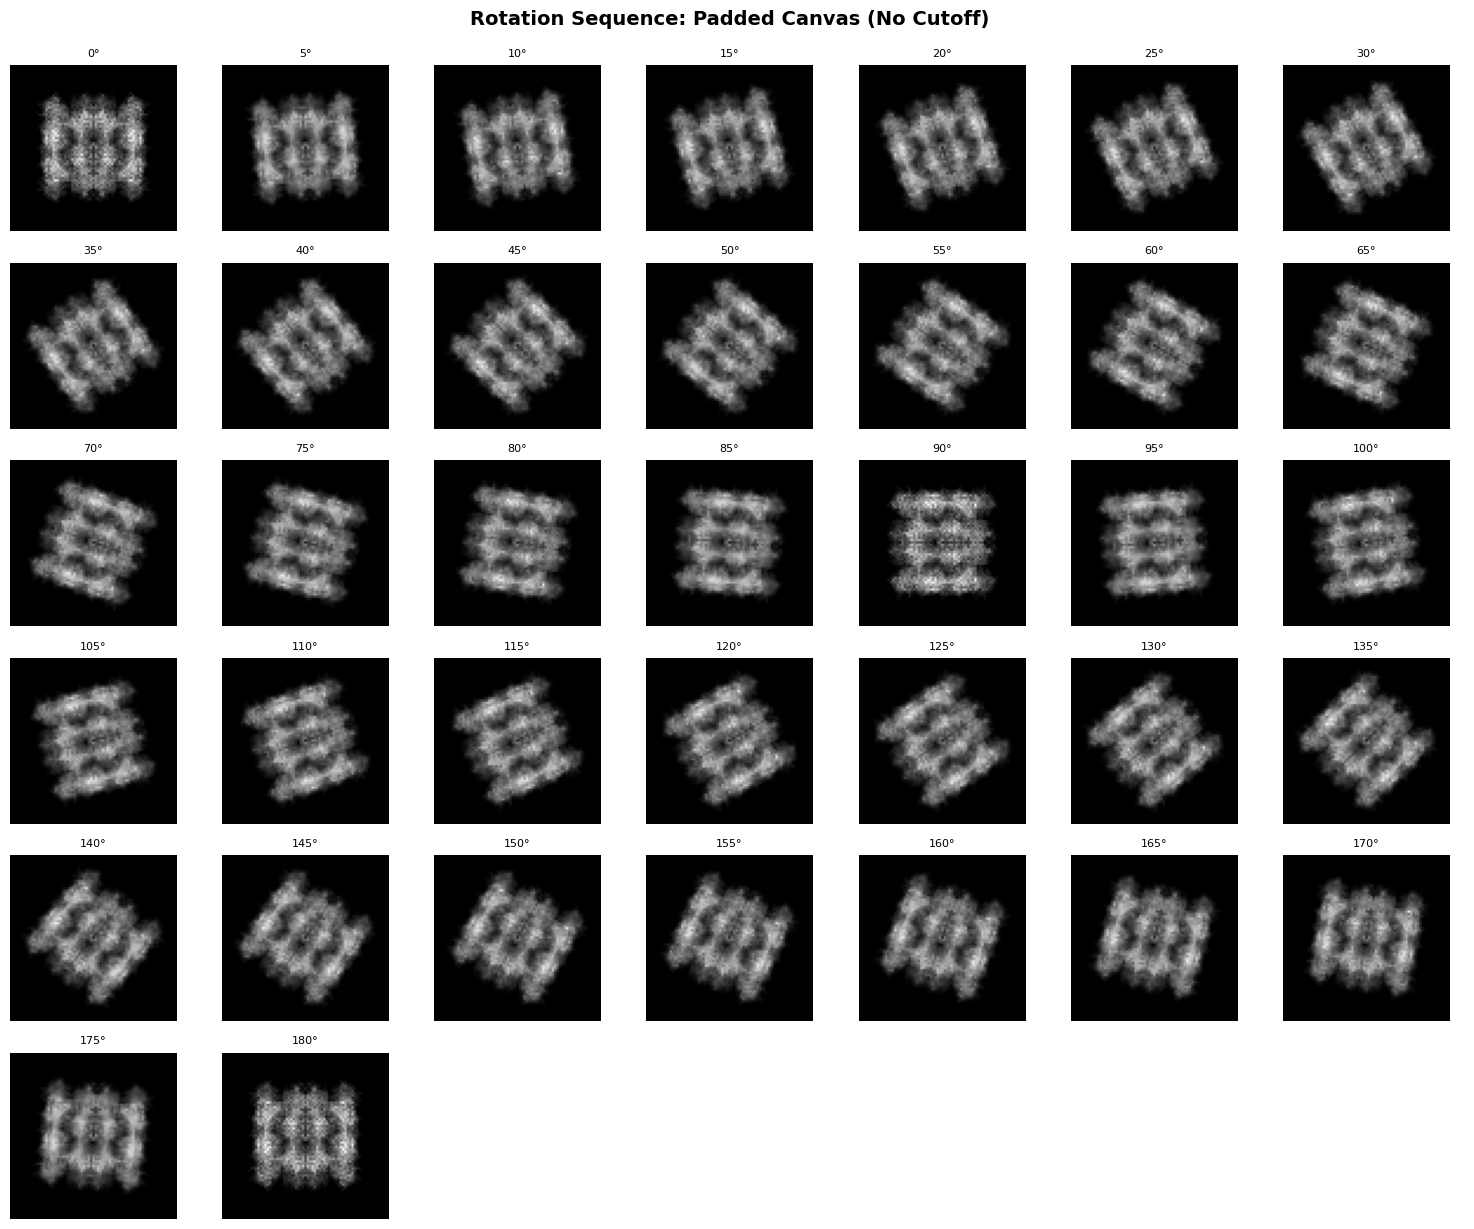

In [134]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare the image (Convert to uint8)
image_uint8 = (proj_xz * 255).astype(np.uint8)

# 2. Pad the image to prevent cutoff
h, w = image_uint8.shape[:2]
# Calculate diagonal to find the minimum square size that fits all rotations
diagonal = int(np.sqrt(h**2 + w**2))
pad_h = (diagonal - h) // 2
pad_w = (diagonal - w) // 2

# Add padding to all sides
padded_img = cv2.copyMakeBorder(image_uint8, pad_h, pad_h, pad_w, pad_w,
                                cv2.BORDER_CONSTANT, value=0)

# 3. Rotate the padded image
angles = list(range(0, 181, 5))
rotated_images = []

for angle in angles:
    # Use the center of the NEW (padded) image
    h_new, w_new = padded_img.shape[:2]
    center = (w_new // 2, h_new // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Rotate within the padded canvas
    rotated = cv2.warpAffine(padded_img, M, (w_new, h_new),
                             flags=cv2.INTER_LINEAR,
                             borderValue=0)
    rotated_images.append(rotated)

# 4. Visualize
fig, axes = plt.subplots(6, 7, figsize=(15, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(rotated_images):
        ax.imshow(rotated_images[i], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{angles[i]}°', fontsize=8)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.suptitle('Rotation Sequence: Padded Canvas (No Cutoff)', fontsize=14, fontweight='bold', y=1.02)
plt.show()